# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Tạ Tuấn Khải"  # TODO: Họ và tên
STUDENT_ID = "2452515"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Tạ Tuấn Khải (2452515)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Khai\Documents\GitHub\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
row_max = np.max(logits, axis=1, keepdims=True)

shifted_logits = logits - row_max

exp_logits = np.exp(shifted_logits)

class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

predicted_classes = np.argmax(class_probabilities, axis=1)

confidence_scores = np.max(class_probabilities, axis=1)

print("shifted_logits:")
print(shifted_logits)

print("\nclass_probabilities:")
print(class_probabilities)

print("\npredicted_classes:")
print(predicted_classes)

print("\nconfidence_scores:")
print(confidence_scores)

print("\nrow sums:")
print(class_probabilities.sum(axis=1))

shifted_logits:
[[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]

class_probabilities:
[[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]

predicted_classes:
[0 1 2 0]

confidence_scores:
[0.65900114 0.66524096 0.97555875 0.33333333]

row sums:
[1. 1. 1. 1.]


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
correct_mask = predicted_classes == true_labels

high_confidence_mask = confidence_scores >= confidence_threshold

review_mask = (~correct_mask) | (~high_confidence_mask)

review_indices = np.where(review_mask)[0]

print("predicted_classes:", predicted_classes)
print("true_labels:", true_labels)
print("confidence_scores:", confidence_scores)

print("correct_mask:", correct_mask)
print("high_confidence_mask:", high_confidence_mask)
print("review_mask:", review_mask)
print("review_indices:", review_indices)

predicted_classes: [0 1 2 0]
true_labels: [0 2 2 1]
confidence_scores: [0.65900114 0.66524096 0.97555875 0.33333333]
correct_mask: [ True False  True False]
high_confidence_mask: [False False  True False]
review_mask: [ True  True False  True]
review_indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = normalized_batch[:, :, ::-1, :].copy()

augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng trong dataset đại diện cho một mẫu xe.
2. Ký hiệu missing value trong file CSV là dấu `?`.
3. `symboling` là mức độ rủi ro bảo hiểm của xe. Giá trị dương cao hơn thường thể hiện xe có rủi ro cao hơn, còn giá trị âm thể hiện xe an toàn hơn theo thang đánh giá của dataset.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
raw_df = pd.read_csv(DATA_PATH)

raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()

print("Raw shape:", raw_shape)
print("Total '?' markers:", raw_missing_marker_count)

raw_df.head()

Raw shape: (205, 26)
Total '?' markers: 59


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
df_clean = raw_df.replace("?", np.nan).copy()

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

missing_by_column = df_clean.isna().sum()

print("Missing values by column:")
print(missing_by_column[missing_by_column > 0])

print("\nData types after cleaning:")
print(df_clean.dtypes)

Missing values by column:
normalized_losses    41
num_doors             2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64

Data types after cleaning:
symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_doors                str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_cylinders            str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: obje

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

Không nên fill tất cả numeric columns bằng cùng một giá trị vì mỗi cột có đơn vị và phân phối khác nhau. Ví dụ, `price`, `horsepower`, `bore` và `normalized_losses` không cùng thang đo, nên một giá trị fill chung sẽ làm sai ý nghĩa dữ liệu.

Với `price`, cách phù hợp cho bài EDA này là drop các dòng thiếu giá. `price` là biến phân tích chính, và số dòng thiếu không nhiều, nên drop giúp biểu đồ và correlation đáng tin cậy hơn.

`normalized_losses` thiếu nhiều dữ liệu nhất. Nếu dùng cột này để phân tích hoặc train model, kết quả có thể bị lệch vì phần dữ liệu còn lại không đại diện đầy đủ cho toàn bộ dataset.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).copy()

X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)

auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("X_auto shape:", X_auto.shape)
print("auto_feature_mean shape:", auto_feature_mean.shape)
print("auto_feature_std shape:", auto_feature_std.shape)
print("X_auto_scaled shape:", X_auto_scaled.shape)

print("\nScaled mean:")
print(np.round(X_auto_scaled.mean(axis=0), 3))

print("\nScaled std:")
print(np.round(X_auto_scaled.std(axis=0), 3))

analysis_df shape: (199, 26)
X_auto shape: (199, 6)
auto_feature_mean shape: (6,)
auto_feature_std shape: (6,)
X_auto_scaled shape: (199, 6)

Scaled mean:
[ 0.  0.  0. -0.  0. -0.]

Scaled std:
[1. 1. 1. 1. 1. 1.]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
price_index = analysis_df.columns.get_loc("price")
price_values = analysis_df["price"].to_numpy(dtype=np.float64)

price_z = (price_values - price_values.mean()) / price_values.std()
price_outlier_mask = np.abs(price_z) > 2

price_outliers = analysis_df.loc[price_outlier_mask].copy()
price_outliers["price_z"] = price_z[price_outlier_mask]

print("price_index:", price_index)
print("Number of price outliers:", price_outlier_mask.sum())

price_outliers[["make", "body_style", "horsepower", "engine_size", "price", "price_z"]]

price_index: 25
Number of price outliers: 14


,make,body_style,horsepower,engine_size,price,price_z
15,bmw,sedan,182.0,209,30760.0,2.200951
16,bmw,sedan,182.0,209,41315.0,3.527184
17,bmw,sedan,182.0,209,36880.0,2.969927
47,jaguar,sedan,176.0,258,32250.0,2.388169
48,jaguar,sedan,176.0,258,35550.0,2.802813
49,jaguar,sedan,262.0,326,36000.0,2.859356
70,mercedes-benz,sedan,123.0,183,31600.0,2.306497
71,mercedes-benz,sedan,155.0,234,34184.0,2.631176
72,mercedes-benz,convertible,155.0,234,35056.0,2.740742
73,mercedes-benz,sedan,184.0,308,40960.0,3.482578


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
d5_df = df_clean.dropna(subset=["engine_size", "price", "body_style"]).copy()

engine_size_values = d5_df["engine_size"].to_numpy(dtype=np.float64)
price_values = d5_df["price"].to_numpy(dtype=np.float64)

engine_price_corr = np.corrcoef(engine_size_values, price_values)[0, 1]

price_by_body_style = (
    d5_df
    .groupby("body_style")["price"]
    .mean()
    .sort_index()
)

print("Correlation between engine_size and price:")
print(round(engine_price_corr, 3))

print("\nMean price by body_style:")
print(price_by_body_style.round(2))

Correlation between engine_size and price:
0.872

Mean price by body_style:
body_style
convertible    21890.50
hardtop        22208.50
hatchback       9957.44
sedan          14459.76
wagon          12371.96
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

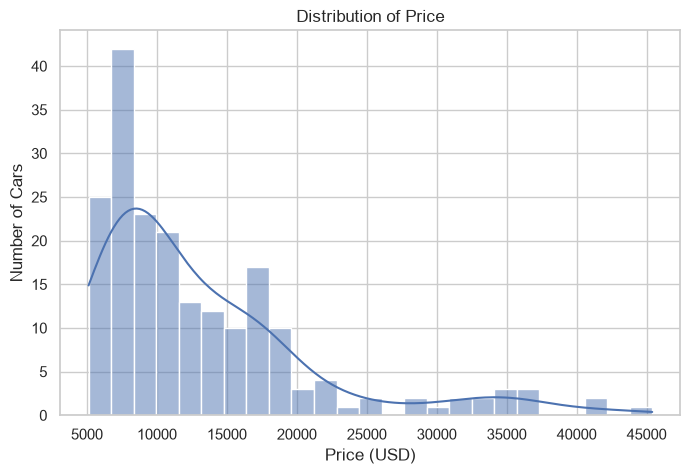

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    analysis_df["price"],
    bins=25,
    kde=True
)

plt.title("Distribution of Price")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Cars")
plt.grid(True)
plt.show()

**Nhận xét**

Price bị lệch phải rõ rệt. Phần lớn xe nằm trong khoảng khoảng 5,000 đến 15,000 USD, trong khi chỉ có một số ít xe rất đắt trên 30,000 USD.

Điều này cho thấy nhóm xe giá cao là nhóm hiếm trong dataset.

## M2.2 Dataset có cân bằng theo body style không?

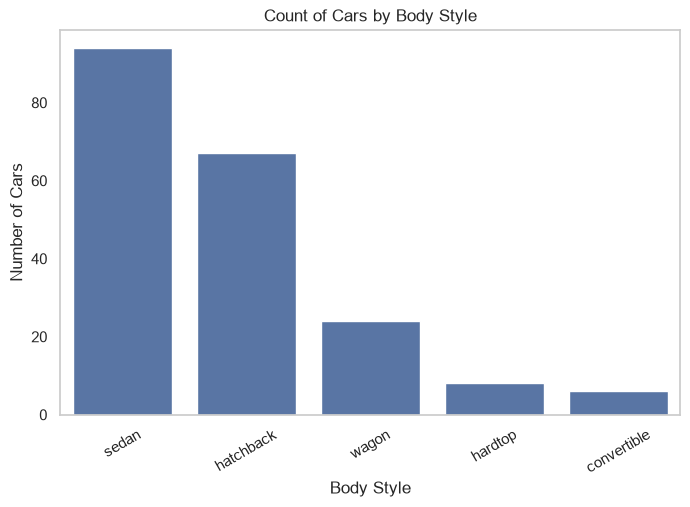

In [21]:
plt.figure(figsize=(8, 5))

body_style_order = analysis_df["body_style"].value_counts().index

sns.countplot(
    data=analysis_df,
    x="body_style",
    order=body_style_order
)

plt.title("Count of Cars by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Number of Cars")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

**Nhận xét**

Dataset không cân bằng theo `body_style`. Sedan và hatchback xuất hiện nhiều nhất, còn wagon, hardtop và convertible có ít mẫu hơn nhiều.

Vì vậy, các nhận xét về nhóm sedan và hatchback sẽ ổn định hơn so với các nhóm ít mẫu.

## M2.3 Price khác nhau theo body style ra sao?

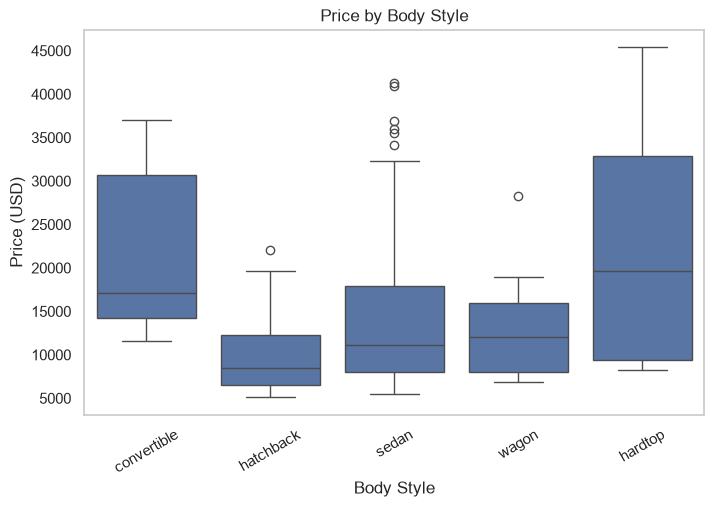

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_df,
    x="body_style",
    y="price"
)

plt.title("Price by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price (USD)")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

**Nhận xét**

Giá xe khác nhau khá rõ giữa các body style. Hardtop và convertible có xu hướng giá cao hơn và khoảng giá rộng hơn.

Hatchback thường rẻ hơn, còn sedan có nhiều mẫu và có vài outlier giá cao.

## M2.4 Engine size liên quan thế nào tới price?

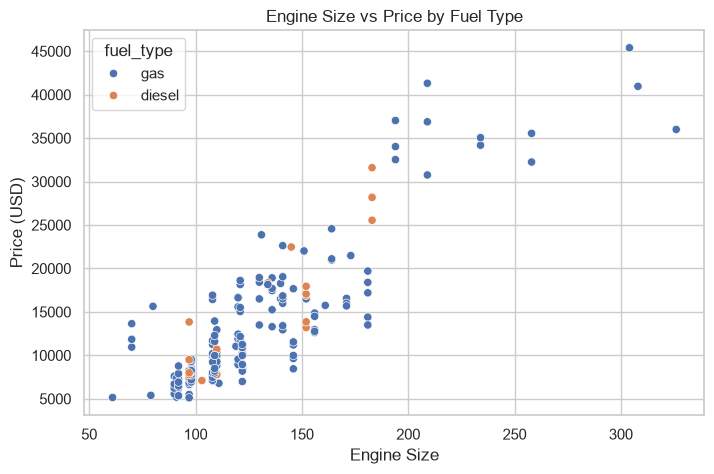

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=analysis_df,
    x="engine_size",
    y="price",
    hue="fuel_type"
)

plt.title("Engine Size vs Price by Fuel Type")
plt.xlabel("Engine Size")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

**Nhận xét**

`engine_size` có quan hệ dương với `price`. Xe có engine size lớn hơn thường có giá cao hơn.

Phần lớn mẫu dùng nhiên liệu gas. Nhóm diesel ít mẫu hơn, nên chưa đủ mạnh để so sánh fuel type một cách chắc chắn.

## M2.5 Các feature numeric tương quan ra sao?

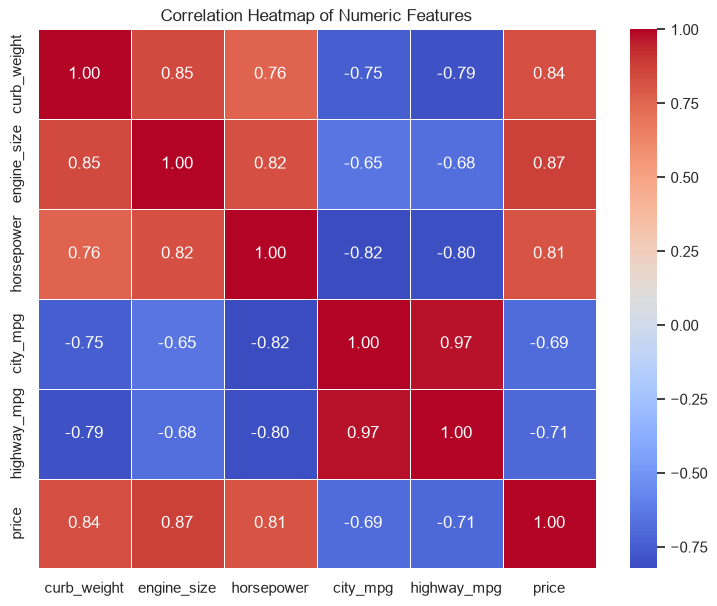

In [24]:
corr_features = list(dict.fromkeys(AUTO_FEATURES + ["price"]))
corr_auto = analysis_df[corr_features].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_auto,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Nhận xét**

Heatmap cho thấy `price` tương quan dương mạnh với `engine_size`, `curb_weight` và `horsepower`.

`city_mpg` và `highway_mpg` tương quan dương rất mạnh với nhau. Hai biến này cũng tương quan âm với `price`, `engine_size` và `horsepower`, cho thấy xe mạnh hơn hoặc nặng hơn thường tiêu hao nhiên liệu nhiều hơn.

## M2.6 Biểu đồ tự chọn

**Câu hỏi:** Drive wheels có liên quan như thế nào đến giá trung bình của xe?

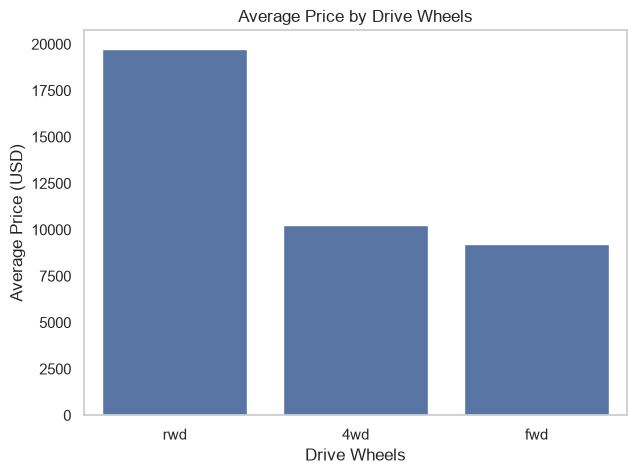

drive_wheels
rwd    19757.61
4wd    10241.00
fwd     9238.74
Name: price, dtype: float64

In [25]:
avg_price_by_drive = (
    analysis_df
    .groupby("drive_wheels")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=avg_price_by_drive.index,
    y=avg_price_by_drive.values
)

plt.title("Average Price by Drive Wheels")
plt.xlabel("Drive Wheels")
plt.ylabel("Average Price (USD)")
plt.grid(axis="y")
plt.show()

avg_price_by_drive.round(2)

**Nhận xét**

Xe rear-wheel drive có giá trung bình cao nhất. Xe front-wheel drive có giá trung bình thấp nhất.

Điều này gợi ý `drive_wheels` có liên quan đến phân khúc giá, nhưng cần kiểm tra thêm với các biến như brand, engine size và horsepower.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Giá xe trong dataset có phân phối lệch phải. Phần lớn mẫu nằm trong khoảng 5,000 đến 15,000 USD, trong khi nhóm trên 30,000 USD xuất hiện khá ít. Số lượng xe theo `body_style` cũng không đồng đều. Sedan và hatchback chiếm đa số, còn hardtop và convertible có ít quan sát hơn.

Các biểu đồ cho thấy giá thay đổi rõ theo kiểu thân xe. Hardtop và convertible thường nằm ở nhóm giá cao, còn hatchback có xu hướng rẻ hơn. Scatterplot giữa `engine_size` và `price` cho thấy quan hệ dương. Xe có động cơ lớn thường đi kèm mức giá cao. Heatmap cũng cho kết quả tương tự, khi `price` tương quan mạnh với `engine_size`, `curb_weight` và `horsepower`. Ngược lại, `city_mpg` và `highway_mpg` tương quan âm với `price`, cho thấy xe nặng hơn và mạnh hơn thường tiêu hao nhiên liệu nhiều hơn.

Dataset vẫn có một số hạn chế. Một số cột còn missing values, gồm `normalized_losses`, `bore`, `stroke`, `horsepower`, `peak_rpm` và `price`. Ngoài ra, vài nhóm thân xe như convertible và hardtop có số mẫu thấp, nên kết luận so sánh giữa các nhóm này chưa thật ổn định.

Correlation không đồng nghĩa với causation. `engine_size` có tương quan cao với `price`, nhưng điều này không chứng minh động cơ lớn là nguyên nhân trực tiếp làm giá xe tăng. Các yếu tố khác như thương hiệu, phân khúc, trang bị, loại thân xe và `horsepower` cũng có thể ảnh hưởng đến giá.

Câu hỏi nên phân tích tiếp: nhóm feature nào dự đoán giá xe tốt nhất, và mức đóng góp của từng feature vào dự đoán là bao nhiêu?